# Classification of Ice and Open Water of Yukon River using Sentinel-1 IW Product

This notebook classifies ice and open water in the Yukon River using Sentinel-1 SAR imagery from September to May during the 2022, 2023, and 2024 winter seasons. The code from this notebook was adapted from code samples found on Copernicus's Data Space Ecosystem Documentation page: https://documentation.dataspace.copernicus.eu/notebook-samples/sentinelhub/ice_monitoring.html

The Tanana River Confluence connects the Yukon River to the Tanana River, which is a major shipping artery. Nenana, located on the Tanana River, is a central hub for Ruby Marine that transports heavy goods, oil, and vehicles for inland communities.

## Imports

In [46]:
import datetime
import getpass

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import geopandas as gpd
import json
from ipyleaflet import Map, GeoJSON, basemaps

from sentinelhub import (
    SHConfig,
    Geometry,
    DataCollection,
    MimeType,
    SentinelHubDownloadClient,
    SentinelHubRequest,
    bbox_to_dimensions,
    SentinelHubCatalog, BBox, CRS,
)

## Credentials

In [47]:
# Input Sentinel Hub credentials
config = SHConfig()
#TODO - change to getpass.getpass() to avoid hardcoding credentials
config.sh_client_id = "sh-03b97588-8780-4ec9-b187-9f18c5aa9b8e"
config.sh_client_secret = "yr1wbYiDybefN5L6utkT2KzwDPhq48rW"
config.sh_token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
config.sh_base_url = "https://sh.dataspace.copernicus.eu"

## Defining the Bounds

In [48]:
# Load the river geometry from the GeoJSON file
SHAPE_PATH = "../data/raw/confluence_aoi.geojson"
river_gdf = gpd.read_file(SHAPE_PATH)

# Reproject temporarily just for metric resolution calculation
river_gdf_metric = river_gdf.to_crs("EPSG:32606")  # UTM zone 3N, meters-based
resolution = 40
print("Bounds:", river_gdf_metric.total_bounds)

# Keep river geometry in WGS84 for Sentinel Hub requests and visualization
river_gdf = river_gdf.to_crs("EPSG:4326")


# Load the GeoJSON data for visualization
data_geojson = json.load(open(SHAPE_PATH, "r"))

# Set center and zoom level
center = [65.17, -152.03]
zoom = 11

# Build and display interactive map
m = Map(basemap=basemaps.CartoDB.Voyager, center=center, zoom=zoom)
geo_json = GeoJSON(data=data_geojson)
m.add_layer(geo_json)
m

Bounds: [ 253843.19914737 7232950.54977846  273941.5935925  7239963.3757012 ]


Map(center=[65.17, -152.03], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom…

## Check Sentinel Hub for available imagery

In [49]:
# Define date range for Sentinel-1 data
START_YEARS = [2022, 2023, 2024]
date_ranges = [(f"{year}-09-01", f"{year+1}-05-31") for year in START_YEARS]

# Query Sentinel Hub Catalog for Sentinel-1 IW data intersecting the river geometry
catalog = SentinelHubCatalog(config=config)
bbox = BBox(tuple(river_gdf.total_bounds), crs=CRS.WGS84)

all_results = []
for i, year in enumerate(START_YEARS):
    results = list(catalog.search(
        DataCollection.SENTINEL1_IW.define_from("s1iw", service_url=config.sh_base_url),
        bbox=bbox,
        time=date_ranges[i],  # pass the individual tuple for this year
        fields={"include": ["id", "properties.datetime", "properties.orbitDirection"], "exclude": []}
    ))
    all_results.extend(results)
    print(f"{year}-{year+1} Sep-May: {len(results)} scenes found")

print(f"\nTotal scenes found: {len(all_results)}")

2022-2023 Sep-May: 40 scenes found
2023-2024 Sep-May: 43 scenes found
2024-2025 Sep-May: 56 scenes found

Total scenes found: 139


## Define Time Slots

In [50]:
# Split each September – May season into 16 bi-monthly slots to capture freeze-thaw dynamics.
season_slots = {}
for year in START_YEARS:
    start = datetime.datetime(year, 9, 1)
    end = datetime.datetime(year + 1, 5, 31)
    n_chunks = 19
    tdelta = (end - start) / n_chunks
    edges = [(start + i * tdelta).date().isoformat() for i in range(n_chunks)]
    season_slots[year] = [(edges[i], edges[i + 1]) for i in range(len(edges) - 1)]

    print(f"\n{year}-{year + 1}: Monthly time windows:\n")
    for slot in season_slots[year]:
        print(slot)


2022-2023: Monthly time windows:

('2022-09-01', '2022-09-15')
('2022-09-15', '2022-09-29')
('2022-09-29', '2022-10-13')
('2022-10-13', '2022-10-28')
('2022-10-28', '2022-11-11')
('2022-11-11', '2022-11-25')
('2022-11-25', '2022-12-10')
('2022-12-10', '2022-12-24')
('2022-12-24', '2023-01-07')
('2023-01-07', '2023-01-22')
('2023-01-22', '2023-02-05')
('2023-02-05', '2023-02-19')
('2023-02-19', '2023-03-06')
('2023-03-06', '2023-03-20')
('2023-03-20', '2023-04-03')
('2023-04-03', '2023-04-18')
('2023-04-18', '2023-05-02')
('2023-05-02', '2023-05-16')

2023-2024: Monthly time windows:

('2023-09-01', '2023-09-15')
('2023-09-15', '2023-09-29')
('2023-09-29', '2023-10-14')
('2023-10-14', '2023-10-28')
('2023-10-28', '2023-11-11')
('2023-11-11', '2023-11-26')
('2023-11-26', '2023-12-10')
('2023-12-10', '2023-12-24')
('2023-12-24', '2024-01-08')
('2024-01-08', '2024-01-22')
('2024-01-22', '2024-02-06')
('2024-02-06', '2024-02-20')
('2024-02-20', '2024-03-05')
('2024-03-05', '2024-03-20')
('

## Requesting Sentinel-1 (SAR) Data

The evalscript below:
- Inputs the VV band and dataMask
- Converts linear backscatter to decibels (dB), scaled to [0, 1]
- Outputs FLOAT32 values for further analysis

Pre-processing applied:
- **Radiometric calibration**: `SIGMA0_ELLIPSOID`
- **Speckle filter**: LEE 3×3
- **Geometric correction**: COPERNICUS DEM
- **Resolution**: HIGH (40 m × 40 m), ascending orbit

In [51]:
evalscript_sar = """
  function setup() {
    return {
      input: ["VV", "dataMask"],
      output: { bands: 2, sampleType: "FLOAT32"}
    }
  }

// visualizes decibels from -20 to +10
function toDb(linear) {
  var log = 10 * Math.log(linear) / Math.LN10
  return Math.max(0, (log + 20) / 30)
}

function evaluatePixel(sample) {
  var VV = sample.VV;
  return [toDb(VV), sample.dataMask];
}
"""


def get_sar_request(time_interval):
    return SentinelHubRequest(
        evalscript=evalscript_sar,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=DataCollection.SENTINEL1_IW.define_from(
                    "s1iw", service_url=config.sh_base_url
                ),
                time_interval=time_interval,
                other_args={
                    "dataFilter": {
                        "resolution": "HIGH",
                        "mosaickingOrder": "mostRecent",
                    },
                    "processing": {
                        "backCoeff": "SIGMA0_ELLIPSOID",
                        "orthorectify": True,
                        "demInstance": "COPERNICUS",
                        "speckleFilter": {
                            "type": "LEE",
                            "windowSizeX": 3,
                            "windowSizeY": 3,
                        },
                    },
                },
            )
        ],
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
        geometry=Geometry(river_gdf_metric.geometry.values[0], crs=river_gdf_metric.crs),
        resolution=[40, 40],
        config=config,
        data_folder="../data/results",
    )

In [52]:
# Create and download all SAR requests
season_sar_data = {}
for year, slots in season_slots.items():
    print(f"Downloading SAR data for {year}/{year+1}...")
    reqs = [get_sar_request(slot) for slot in slots]
    reqs = [r.download_list[0] for r in reqs]
    season_sar_data[year] = SentinelHubDownloadClient(config=config).download(
        reqs, max_threads=1
    )

### Visualize SAR Imagery (VV Band)

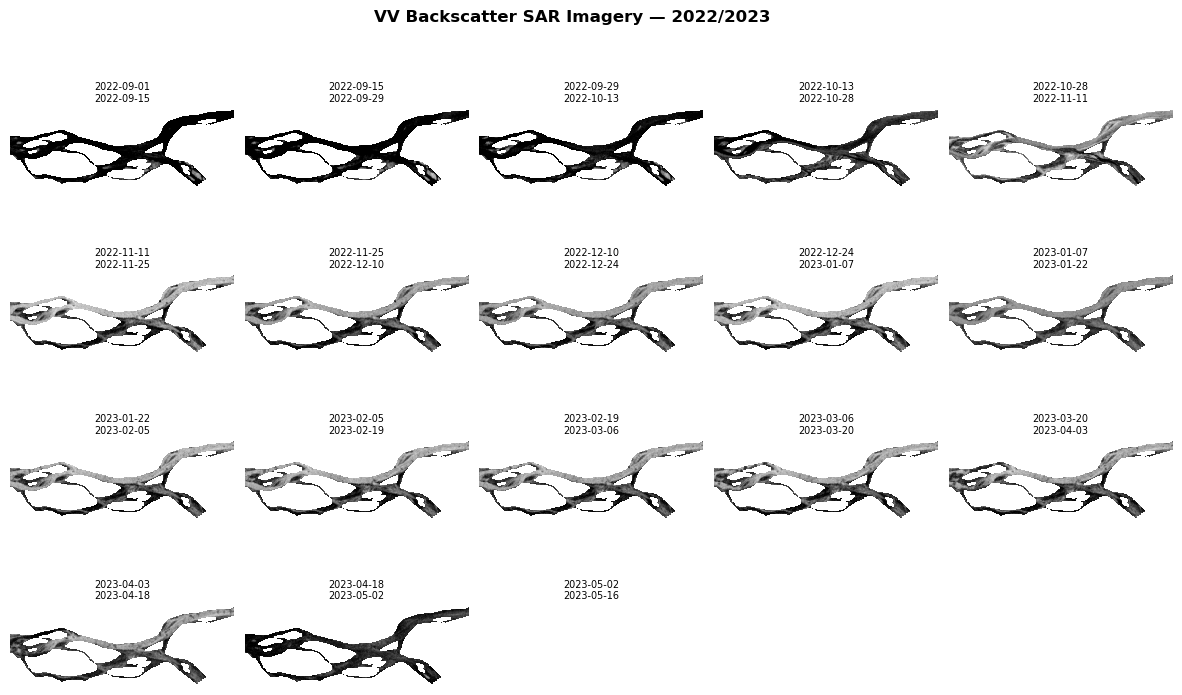

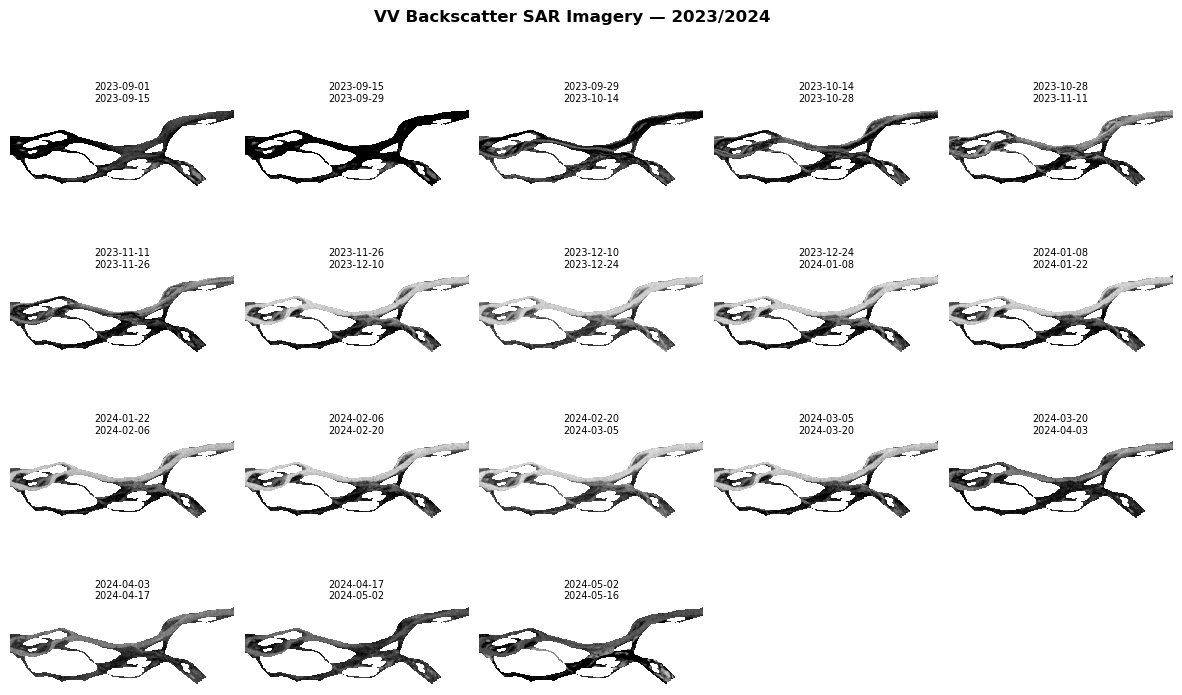

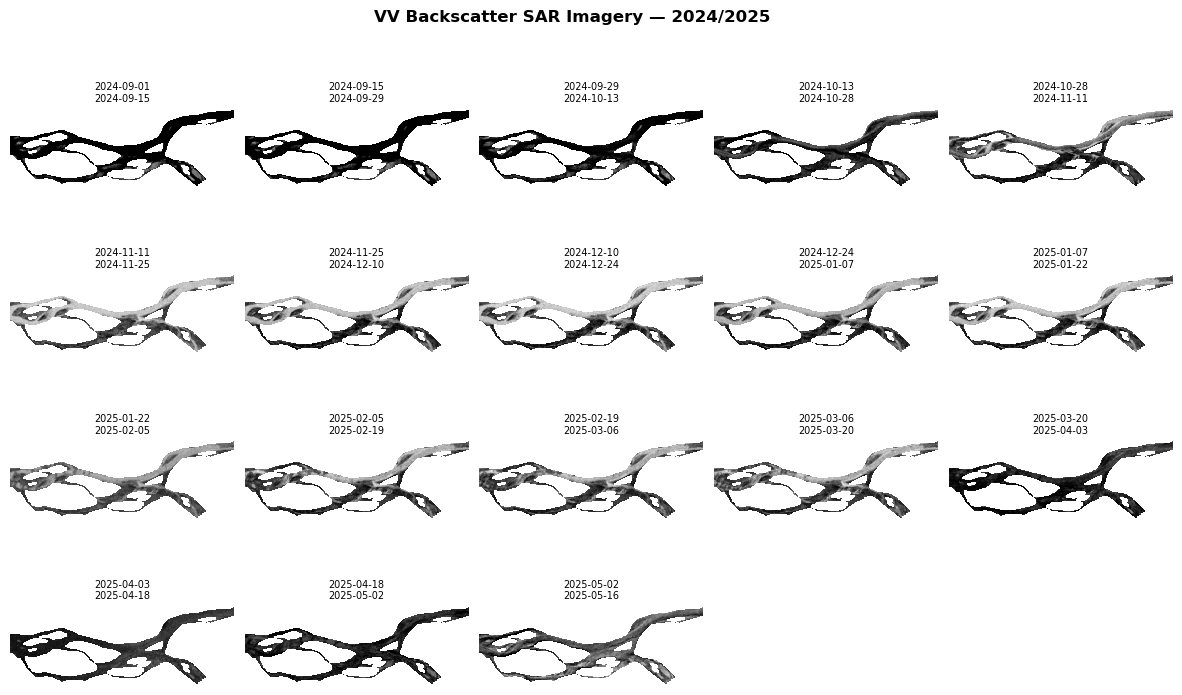

In [53]:
# Create a 4x4 grid of subplots to visualize the 16 bi-monthly SAR images.
ncols = 5
subplot_kw = {"xticks": [], "yticks": [], "frame_on": False}

for year, slots in season_slots.items():
    data = season_sar_data[year]
    nrows = int(np.ceil(len(slots) / ncols))

    fig, axs = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(ncols * 3, nrows * 2),
        subplot_kw=subplot_kw,
    )
    fig.suptitle(f"VV Backscatter SAR Imagery — {year}/{year + 1}", fontsize=12, fontweight="bold")

    for idx, image in enumerate(data):
        ax = axs[idx // ncols][idx % ncols]
        ax.imshow(np.clip(image[:, :, 0], 0, 1), cmap="gray")
        ax.set_title(f"{slots[idx][0]}\n{slots[idx][1]}", fontsize=7)

    # Hide unused axes in the last row
    for idx in range(len(data), nrows * ncols):
        axs[idx // ncols][idx % ncols].set_visible(False)

    fig.subplots_adjust(hspace=0.4, wspace=0.05)
    plt.savefig(f"../results/images/sar_{year}_{year + 1}.png", dpi=300, bbox_inches="tight")
    plt.show()

## Creating the Ice Mask

 Ice pixels appear brighter (higher backscatter) compared to open water, because ice scatters electromagnetic waves in all directions, increasing the chance of detection by the sensor. Open water, by contrast, acts like a mirror and reflects most energy away from the sensor.

Based on SAR image interpretation of the slots with valid data, an initial threshold of 0.2 (on the normalised 0–1 dB scale, equivalent to 50/255) was evaluated but found to be unsuitable for this study area, as it failed to capture seasonal differences in ice coverage. A revised threshold of 0.45 was selected after visual comparison of summer and winter classifications, which better reflects the higher baseline backscatter of the surrounding boreal terrain along the Yukon River.

Note: Several time slots show no data due to limited Sentinel-1 acquisition frequency over the Yukon River basin. Only slots with available acquisitions produce valid backscatter imagery.


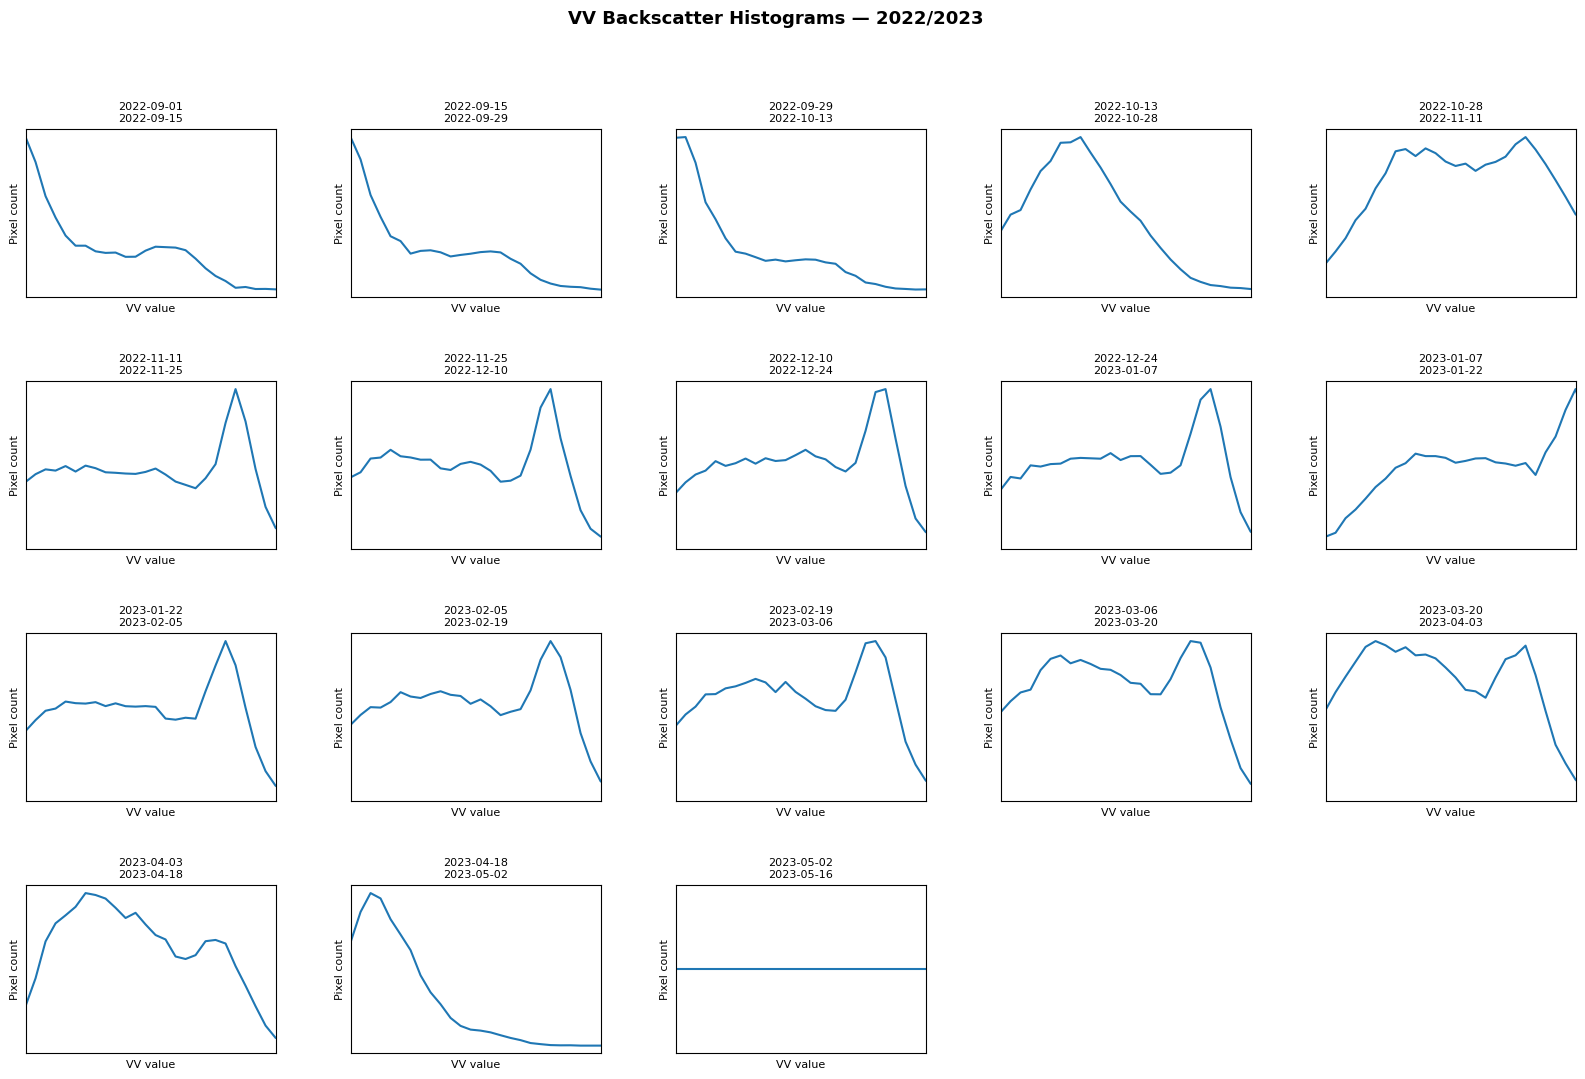

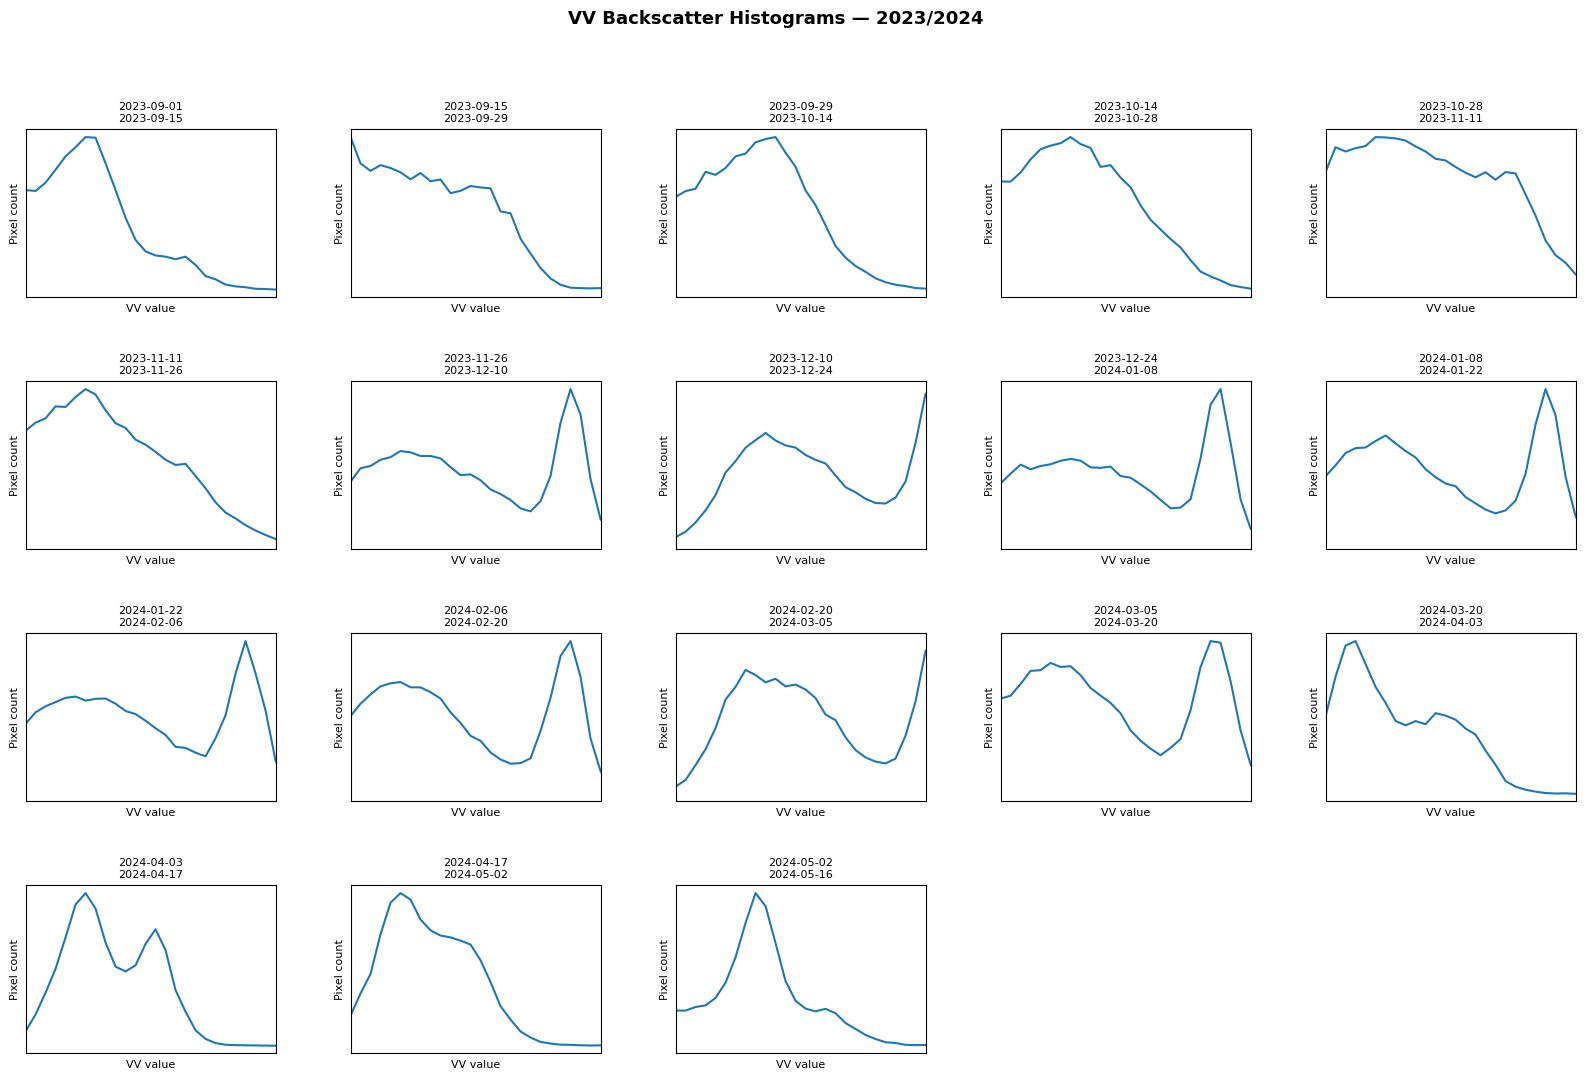

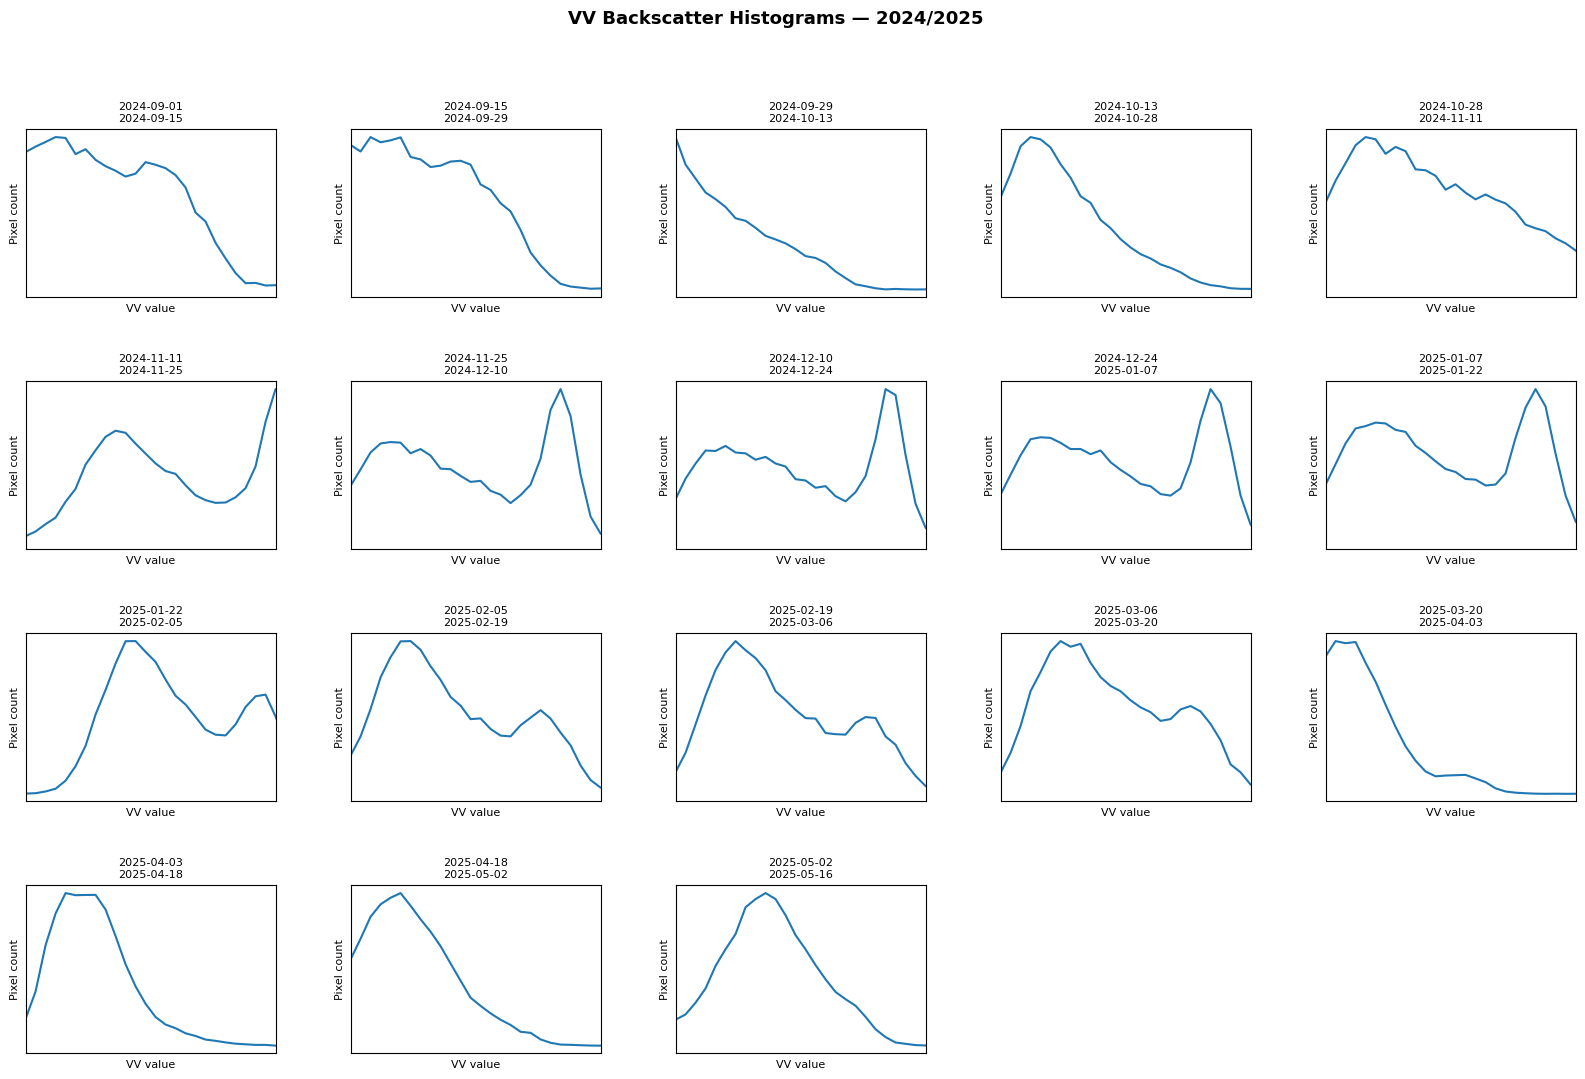

In [54]:
ncols = 5
histogram_subplot_kw = {"xticks": [], "yticks": [], "frame_on": True}

for year, slots in season_slots.items():
    data = season_sar_data[year]
    nrows = int(np.ceil(len(slots) / ncols))

    fig, axs = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(ncols * 4, nrows * 3),
        subplot_kw=histogram_subplot_kw,
    )
    fig.suptitle(f"VV Backscatter Histograms — {year}/{year + 1}", fontsize=13, fontweight="bold")

    for idx, image in enumerate(data):
        histogram, bin_edges = np.histogram(
            image[:, :, 0][~np.isnan(image[:, :, 0])], bins=50, range=(0.0000001, 1)
        )
        ax = axs[idx // ncols][idx % ncols]
        ax.plot(bin_edges[:-1], histogram)
        ax.set_xlabel("VV value", fontsize=8)
        ax.set_ylabel("Pixel count", fontsize=8)
        ax.set_xlim(0, 0.5)
        ax.set_title(f"{slots[idx][0]}\n{slots[idx][1]}", fontsize=8)
        ax.tick_params(labelsize=7)

    for idx in range(len(data), nrows * ncols):
        axs[idx // ncols][idx % ncols].set_visible(False)

    fig.subplots_adjust(hspace=0.5, wspace=0.3)
    plt.savefig(f"../results/figures/VV_backscatter_{year}_{year + 1}.png", dpi=300, bbox_inches="tight")
    plt.show()

## Ice Mask Evalscript and Requests

The evalscript below classifies each pixel:
- **Blue** `[0, 0, 255]` → Open water (VV dB in [0, 0.2])
- **Cyan** `[0, 255, 255]` → Ice (VV dB in [0.45, 1])
- **Black** `[0, 0, 0]` → No data / land

Band 5 (`iceMask`) is `1` for ice pixels and `0` otherwise.

Note: The original threshold of 0.2 was recalibrated to 0.45 for this study area. Visual comparison of fall (September 2022) and winter (January 2023) classifications revealed that 0.2 produced near-identical results across seasons, failing to capture the freeze-thaw cycle, whereas 0.45 correctly showed open water conditions in summer and increased ice coverage in winter, reflecting the expected seasonal dynamics of the Yukon River.

In [55]:
evalscript_mask = """
  function setup() {
    return {
      input: ["VV", "dataMask"],
      output: { bands: 5, sampleType: "UINT8"}
    }
  }

function toDb(linear) {
  var log = 10 * Math.log(linear) / Math.LN10
  return Math.max(0, (log + 20) / 30)
}

function evaluatePixel(sample) {
  var VV = sample.VV;
  var iceMask = 0;
  var VVdB = toDb(VV);
  if (VVdB > -0.001 && VVdB < 0.45) {
    iceMask = 0;
    return [0, 0, 0, sample.dataMask, iceMask]; // Non-ice
  } else if (VVdB >= 0.45 && VVdB < 1) {
    iceMask = 1;
    return [0, 255, 255, sample.dataMask, iceMask]; // Ice
  } else {
    iceMask = 0;
    return [255, 255, 255, sample.dataMask, iceMask]; // No data
  }
}
"""


def get_ice_mask_request(time_interval):
    return SentinelHubRequest(
        evalscript=evalscript_mask,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=DataCollection.SENTINEL1_IW.define_from(
                    "s1iw", service_url=config.sh_base_url
                ),
                time_interval=time_interval,
                other_args={
                    "dataFilter": {
                        "resolution": "HIGH",
                        "mosaickingOrder": "mostRecent",
                    },
                    "processing": {
                        "backCoeff": "SIGMA0_ELLIPSOID",
                        "orthorectify": True,
                        "demInstance": "COPERNICUS",
                        "speckleFilter": {
                            "type": "LEE",
                            "windowSizeX": 3,
                            "windowSizeY": 3,
                        },
                    },
                },
            )
        ],
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
        geometry=Geometry(river_gdf_metric.geometry.values[0], crs=river_gdf_metric.crs),
        resolution=[40, 40],
        config=config,
        data_folder="./results_mask",
    )

In [56]:
# Download ice mask data for all bi-monthly slots across the three seasons.
season_ice_mask_data = {}
for year, slots in season_slots.items():
    print(f"Downloading ice mask data for {year}/{year+1}...")
    reqs = [get_ice_mask_request(slot) for slot in slots]
    reqs = [r.download_list[0] for r in reqs]
    season_ice_mask_data[year] = SentinelHubDownloadClient(config=config).download(
        reqs, max_threads=1
    )

## Visualize Ice/Water Classification Maps

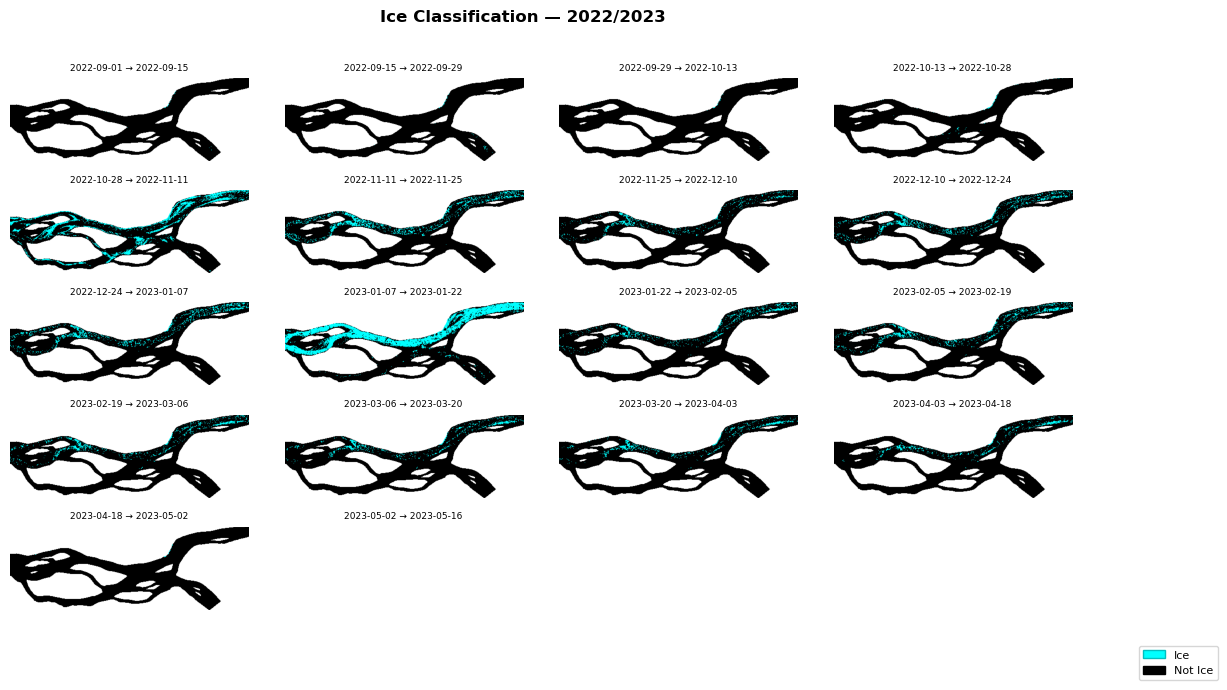

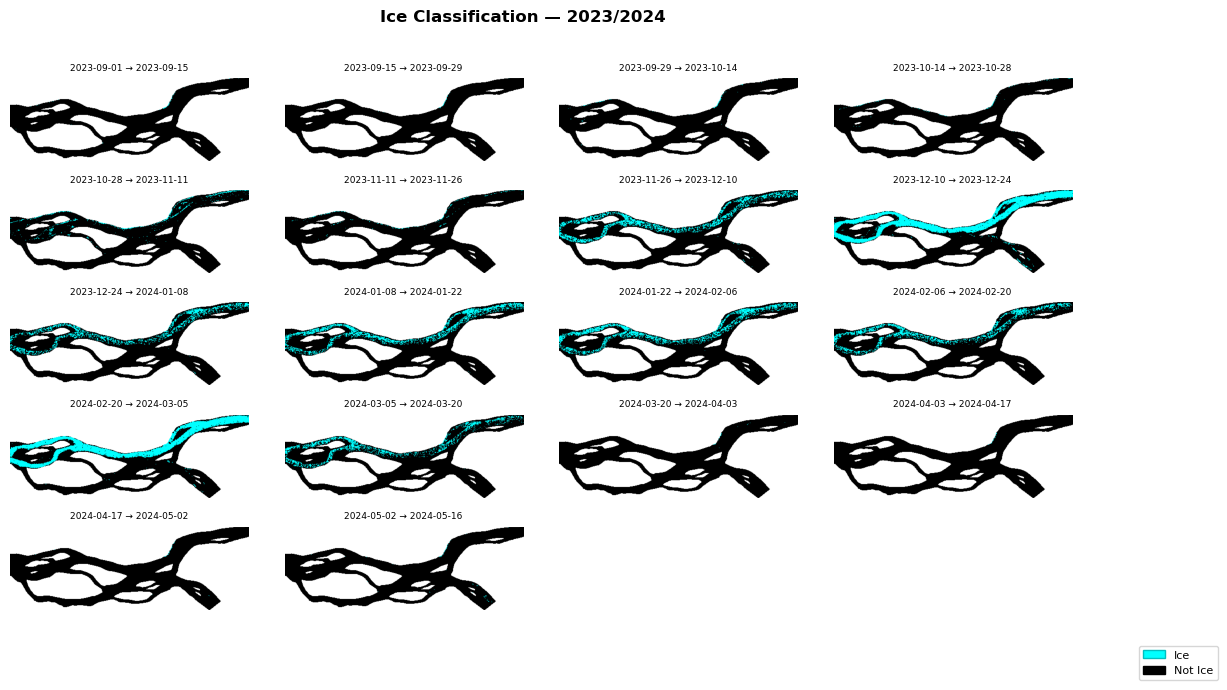

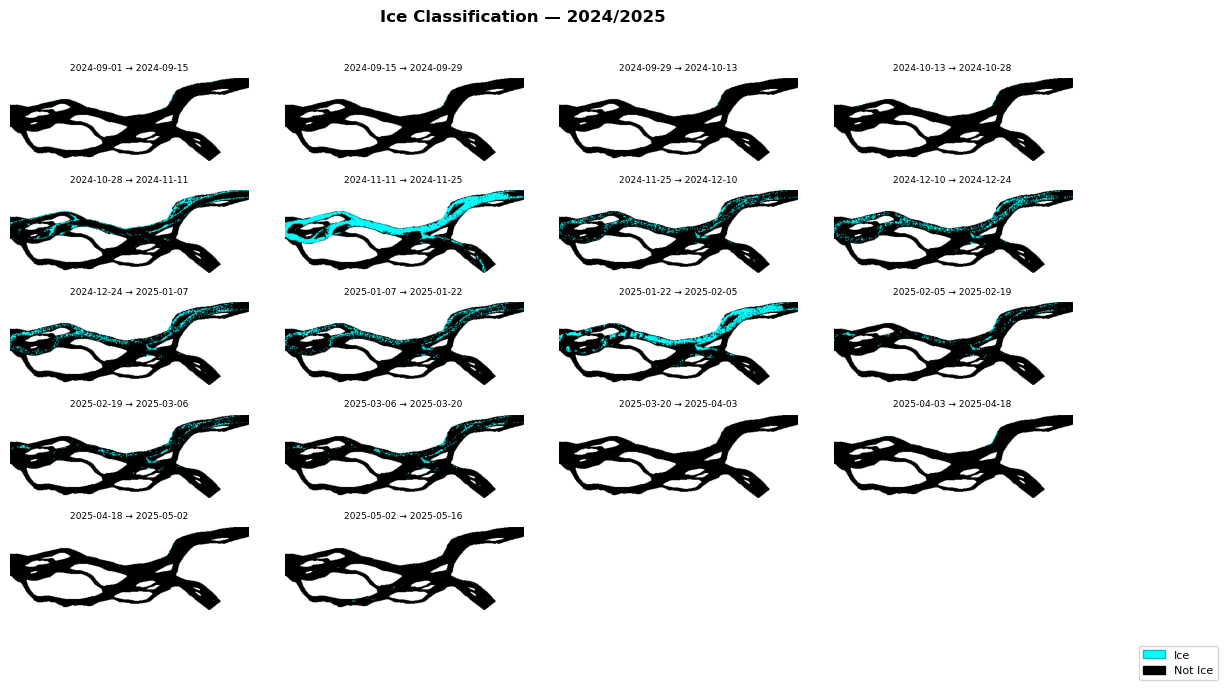

In [ ]:
ncols = 4

sample_image = season_ice_mask_data[START_YEARS[0]][0]
img_height, img_width = sample_image.shape[:2]
panel_aspect = img_width / img_height  # e.g. 4.0 for a wide river AOI

ice_subplot_kw = {"xticks": [], "yticks": [], "frame_on": False}
legend_elements = [
    Patch(facecolor="cyan", edgecolor="c", label="Ice"),
    Patch(facecolor="black", edgecolor="black", label="Open Water"),
]

# Create a 4x4 grid of subplots to visualize the 16 bi-monthly SAR images with ice/water classification.
for year in START_YEARS:
    slots = season_slots[year]
    ice_mask_data = season_ice_mask_data[year]
    nrows = int(np.ceil(len(slots) / ncols))

    panel_w = 3.5
    panel_h = panel_w / panel_aspect
    fig, axs = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(ncols * panel_w, nrows * panel_h + 0.8),
        subplot_kw=ice_subplot_kw,
    )
    fig.suptitle(f"Ice Classification — {year}/{year + 1}", fontsize=12, fontweight="bold")

    for idx, image in enumerate(ice_mask_data):
        ax = axs[idx // ncols][idx % ncols]
        ax.imshow(np.clip(image[:, :, :3], 0, 255))
        # Single line title with arrow separator
        ax.set_title(f"{slots[idx][0]} → {slots[idx][1]}", fontsize=6.5)

    for idx in range(len(ice_mask_data), nrows * ncols):
        axs[idx // ncols][idx % ncols].set_visible(False)

    # Place legend on the figure itself, bottom right, outside the subplots
    fig.legend(
        handles=legend_elements,
        loc="lower right",
        fontsize=8,
        frameon=True,
        bbox_to_anchor=(1.0, 0.0),
    )

    fig.subplots_adjust(hspace=0.35, wspace=0.05)
    plt.savefig(
        f"../results/images/ice_classification_{year}_{year + 1}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

## Creating a Time Series of Ice-Covered Area

Count ice pixels (band 5 == 1) and multiply by the pixel area (40 m × 40 m) to get area in km².

In [58]:
def count_ice_pixels(image):
    ice_mask = image[:, :, 4]
    # Only count valid pixels (dataMask = 1) as the denominator
    valid_pixels = np.sum(image[:, :, 3] > 0)
    ice_pixels = np.sum(ice_mask)
    return (ice_pixels / valid_pixels * 100) if valid_pixels > 0 else 0

In [59]:
# Calculate ice area for each season
resolution_s1 = 40 * 40  # m² per pixel
season_ice_area = {}

for year in START_YEARS:
    season_ice_area[year] = [count_ice_pixels(image) for image in season_ice_mask_data[year]]
    print(f"{year}/{year+1}: max coverage = {max(season_ice_area[year]):.1f}%")

2022/2023: max coverage = 31.3%
2023/2024: max coverage = 30.7%
2024/2025: max coverage = 32.2%


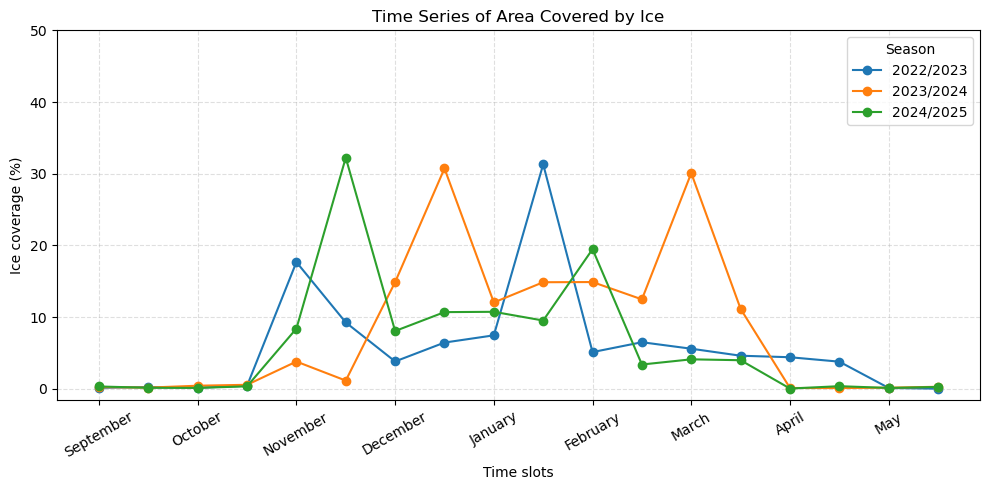

In [60]:
# Plot all three seasons
xlabels = [
    "September",
    "October",
    "November",
    "December",
    "January",
    "February",
    "March",
    "April",
    "May"
]

plt.figure(figsize=(10, 5))

for year in START_YEARS:
    plt.plot(range(len(season_slots[year])), season_ice_area[year], marker="o", label=f"{year}/{year+1}")
plt.title("Time Series of Area Covered by Ice")
plt.xticks(np.arange(0, 18, step=2), xlabels, rotation=30, ha="center")
plt.xlabel("Time slots")
plt.ylabel("Ice coverage (%)")
plt.yticks(np.arange(0, 60, step=10))  # 0-100% in 10% increments
plt.legend(title="Season")
plt.tight_layout()
plt.grid(axis="both", linestyle="--", alpha=0.4)

# Export the time series plot to figures folder
plt.savefig(f"../results/figures/ice_area_{year}_{year+1}.png", dpi=300)


plt.show()

## Summary

- Ice formation in this section of the Tanana section of the Yukon River began in **late October 2022** and peaked through the winter months.
- Once ice breakup began in **late April 2023**, the river cleared rapidly.
- The classification used a VV dB threshold of **0.2** to separate open water (low backscatter) from ice (high backscatter).
- Sentinel-1 SAR data is well-suited for this task as it is unaffected by cloud cover or daylight conditions.

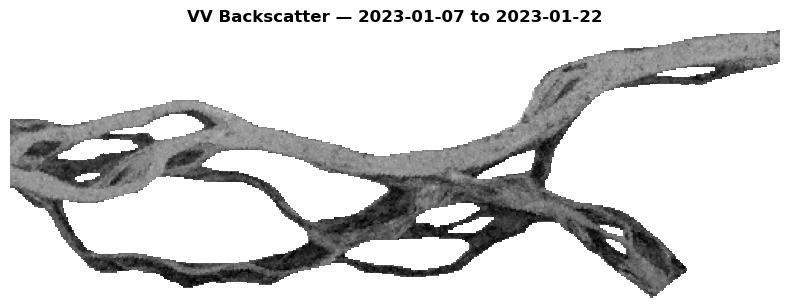

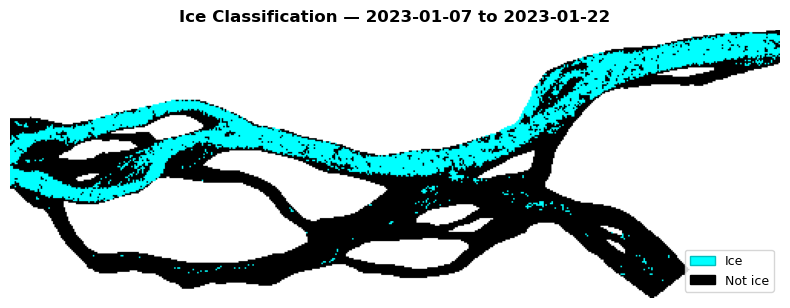

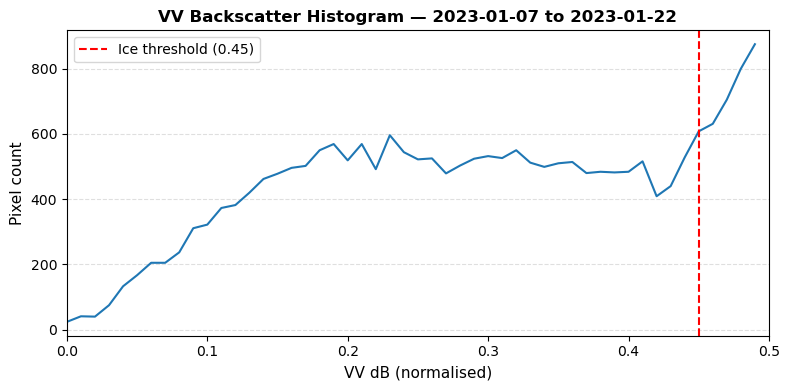

In [ ]:
EXPORT_YEAR = 2022
EXPORT_IDX = 9
EXPORT_SLOT = season_slots[EXPORT_YEAR][EXPORT_IDX]
SLOT_LABEL = f"{EXPORT_SLOT[0]} to {EXPORT_SLOT[1]}"

ICE_THRESHOLD = 0.45

# ── 1. SAR Backscatter ────────────────────────────────────────────────────────
sar_image = season_sar_data[EXPORT_YEAR][EXPORT_IDX]

fig, ax = plt.subplots(figsize=(8, 5))
ax.imshow(np.clip(sar_image[:, :, 0], 0, 1), cmap="gray")
ax.set_title(f"VV Backscatter — {SLOT_LABEL}", fontsize=12, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.savefig(f"../results/images/sar_jan_2023.png", dpi=300, bbox_inches="tight")
plt.show()

# ── 2. Ice Classification ─────────────────────────────────────────────────────
mask_image = season_ice_mask_data[EXPORT_YEAR][EXPORT_IDX]
legend_elements = [
    Patch(facecolor="cyan", edgecolor="c", label="Ice"),
    Patch(facecolor="#000000", edgecolor="#000000", label="Open Water"),
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.imshow(np.clip(mask_image[:, :, :3], 0, 255))
ax.set_title(f"Ice Classification — {SLOT_LABEL}", fontsize=12, fontweight="bold")
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)
ax.axis("off")
plt.tight_layout()
plt.savefig(f"../results/images/ice_classification_jan_2023.png", dpi=300, bbox_inches="tight")
plt.show()

# ── 3. VV Backscatter Histogram ───────────────────────────────────────────────
valid_pixels = sar_image[:, :, 0][~np.isnan(sar_image[:, :, 0])]
histogram, bin_edges = np.histogram(valid_pixels, bins=50, range=(1e-7, 0.5))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(bin_edges[:-1], histogram, linewidth=1.5)
ax.axvline(ICE_THRESHOLD, color="red", linestyle="--", linewidth=1.5,
           label=f"Ice threshold ({ICE_THRESHOLD})")
ax.set_title(f"VV Backscatter Histogram — {SLOT_LABEL}", fontsize=12, fontweight="bold")
ax.set_xlabel("VV dB (normalised)", fontsize=11)
ax.set_ylabel("Pixel count", fontsize=11)
ax.set_xlim(0, 0.5)
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(f"../results/images/histogram_jan_2023.png", dpi=300, bbox_inches="tight")
plt.show()